# Notebook 12b — Caudal IDEAM en El Banco (Magdalena) y Ganadería Caribe (Aracataca) y cierre de la cadena causal

Integra las series históricas de caudal mensual de dos estaciones hidrológicas del IDEAM ---obtenidas del portal DHIME para el periodo 2013--2025--- al análisis de forzamiento climático del proyecto, en este sentido se cierra la cadena causal *La Niña → caudal fluvial → inundación lagunar → mortandad del manglar* planteada en el informe con datos oficiales colombianos. La selección de las dos estaciones obedece a que entre ambas capturan las dos vías hidrológicas independientes que alimentan el sistema CGSM: la entrada central del río Magdalena a través de los canales rehabilitados (El Banco, cuenca de ~265.000 km²) y la entrada oriental de los tributarios menores que drenan la Sierra Nevada de Santa Marta (Ganadería Caribe sobre el río Aracataca, cuenca de ~1.000 km²).

**Insumos:**
- `data/raw/ideam/descargaDhime.csv` (El Banco 25027020, caudal máximo mensual)
- `data/raw/ideam/descargaDhime_ganaderia_caribe.csv` (Ganadería Caribe 29067150, caudal medio mensual)
- `outputs/tables/serie_temporal_ndvi_definitiva.csv`

**Productos:**
- `outputs/tables/caudal_ideam_mensual.csv`
- `outputs/tables/correlacion_caudal_ndvi.csv`
- `outputs/figures/caudal_ideam_series_2013_2025.png`
- `outputs/figures/caudal_vs_ndvi_correlacion.png`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
CSV_BANCO = ROOT / 'data' / 'raw' / 'ideam' / 'descargaDhime_elbanco_medio.csv'
CSV_CARIBE   = ROOT / 'data' / 'raw' / 'ideam' / 'descargaDhime_ganaderia_caribe.csv'
NDVI_CSV     = ROOT / 'outputs' / 'tables' / 'serie_temporal_ndvi_definitiva.csv'
OUT_TAB      = ROOT / 'outputs' / 'tables'
OUT_FIG      = ROOT / 'outputs' / 'figures'
OUT_TAB.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

## 1. Carga, normalización y combinación de las dos estaciones

In [2]:
def cargar_serie(csv, nombre_corto):
    df = pd.read_csv(csv)
    df['date'] = pd.to_datetime(df['Fecha']) + pd.offsets.Day(14)
    df['caudal_m3s'] = pd.to_numeric(df['Valor'], errors='coerce')
    df['estacion'] = nombre_corto
    df['parametro'] = df['Parametro'].iloc[0]
    return df[['date', 'estacion', 'parametro', 'caudal_m3s']].dropna()

banco  = cargar_serie(CSV_BANCO, 'El_Banco_Magdalena')
caribe = cargar_serie(CSV_CARIBE, 'Ganaderia_Caribe_Aracataca')

for nombre, df in [('El Banco', banco), ('Ganadería Caribe', caribe)]:
    print(f'{nombre:20s} | {len(df)} meses | {df.parametro.iloc[0]} | '
          f'media {df.caudal_m3s.mean():.1f} m³/s | rango {df.caudal_m3s.min():.1f}–{df.caudal_m3s.max():.1f}')

El Banco             | 144 meses | Caudal medio mensual | media 3749.6 m³/s | rango 1245.7–6861.1
Ganadería Caribe     | 130 meses | Caudal medio mensual | media 15.8 m³/s | rango 1.7–42.2


## 2. Anomalía estandarizada (z-score) por estación

Se remueve la climatología mensual independientemente para cada estación y se divide por la desviación estándar mensual, así los z-scores de las dos cuencas ---a pesar de las diferencias absolutas de caudal de dos órdenes de magnitud--- quedan en una escala común comparable con las anomalías ERA5-Land, ENSO y NDVI ya documentadas.

In [3]:
def anomalia_z(df):
    df = df.copy()
    df['mes'] = df['date'].dt.month
    clim = df.groupby('mes')['caudal_m3s'].agg(['mean', 'std']).reset_index()
    df = df.merge(clim, on='mes', how='left')
    df['caudal_z'] = (df['caudal_m3s'] - df['mean']) / df['std']
    return df[['date', 'estacion', 'parametro', 'caudal_m3s', 'caudal_z']]

caudal_full = pd.concat([anomalia_z(banco), anomalia_z(caribe)], ignore_index=True)
caudal_full.to_csv(OUT_TAB / 'caudal_ideam_mensual.csv', index=False)
print(caudal_full.groupby('estacion')['caudal_z'].describe())

print(f'\nMeses con anomalía positiva extrema (z > +2):')
extremos = caudal_full[caudal_full['caudal_z'] > 2].sort_values('caudal_z', ascending=False)
print(extremos[['date', 'estacion', 'caudal_m3s', 'caudal_z']].head(15).to_string(index=False))

print(f'\nGuardado: caudal_ideam_mensual.csv')

                            count          mean       std       min       25%  \
estacion                                                                        
El_Banco_Magdalena          144.0 -3.083953e-17  0.960769 -2.037452 -0.756290   
Ganaderia_Caribe_Aracataca  130.0 -2.263147e-17  0.956414 -1.700823 -0.748712   

                                 50%       75%       max  
estacion                                                  
El_Banco_Magdalena         -0.000373  0.626544  2.734157  
Ganaderia_Caribe_Aracataca -0.155185  0.589280  2.601619  

Meses con anomalía positiva extrema (z > +2):
      date                   estacion  caudal_m3s  caudal_z
2022-08-15         El_Banco_Magdalena 5920.911568  2.734157
2022-04-15 Ganaderia_Caribe_Aracataca   25.427235  2.601619
2022-07-15         El_Banco_Magdalena 6110.665242  2.261629
2022-09-15         El_Banco_Magdalena 5646.858220  2.172615
2022-09-15 Ganaderia_Caribe_Aracataca   34.832762  2.141218
2022-12-15 Ganaderia_Caribe_Arac

## 3. Series temporales con eventos ENSO destacados

Las franjas sombreadas marcan los dos eventos ENSO del periodo: El Niño 2015--2016 (donde el caudal cae por sequía sostenida sobre la cordillera) y La Niña 2020--2022 (donde el caudal sube por lluvia anómala persistente sobre la cuenca alta).

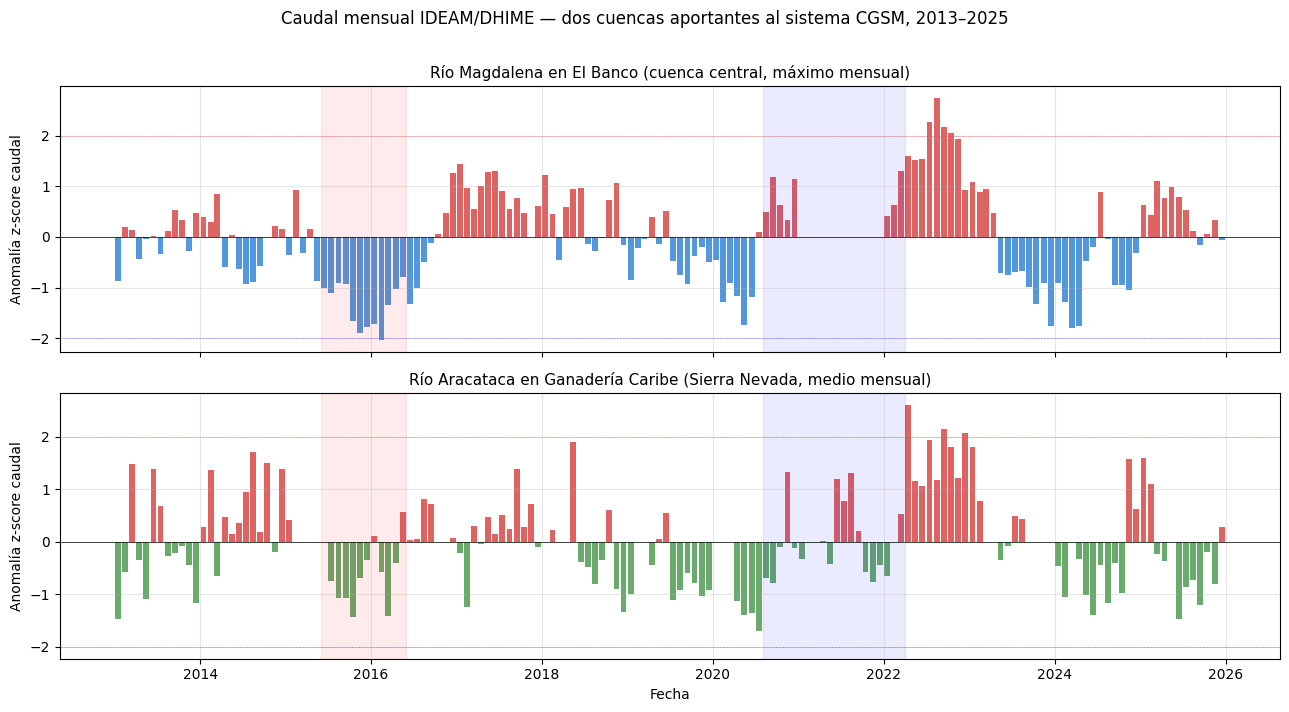

Guardado: caudal_ideam_series_2013_2025.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

config = [
    ('El_Banco_Magdalena',           'Río Magdalena en El Banco (cuenca central, máximo mensual)', '#1976D2'),
    ('Ganaderia_Caribe_Aracataca',   'Río Aracataca en Ganadería Caribe (Sierra Nevada, medio mensual)', '#388E3C'),
]
for ax, (key, titulo, color) in zip(axes, config):
    sub = caudal_full[caudal_full.estacion == key].sort_values('date')
    barras_color = ['#D32F2F' if z > 0 else color for z in sub.caudal_z]
    ax.bar(sub.date, sub.caudal_z, color=barras_color, alpha=0.75, width=25)
    ax.axhline(0, color='black', lw=0.5)
    ax.axhline(2, color='red',  lw=0.4, ls='--', alpha=0.5)
    ax.axhline(-2, color='blue', lw=0.4, ls='--', alpha=0.5)
    ax.axvspan(pd.Timestamp('2015-06-01'), pd.Timestamp('2016-05-31'),
               alpha=0.08, color='red')
    ax.axvspan(pd.Timestamp('2020-08-01'), pd.Timestamp('2022-03-31'),
               alpha=0.08, color='blue')
    ax.set_ylabel('Anomalía z-score caudal')
    ax.set_title(titulo, fontsize=11)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Fecha')
fig.suptitle('Caudal mensual IDEAM/DHIME — dos cuencas aportantes al sistema CGSM, 2013–2025', y=1.01)
plt.tight_layout()
plt.savefig(OUT_FIG / 'caudal_ideam_series_2013_2025.png', dpi=200, bbox_inches='tight')
plt.show()
print('Guardado: caudal_ideam_series_2013_2025.png')

## 4. Correlación caudal vs NDVI z-score por cuenca y naturaleza espectral

Se replica la metodología de los notebooks 07 (ERA5-Land) y 11 (ONI/SOI), desagregando las anomalías NDVI por naturaleza espectral según `tbl-clasif-estaciones`.

In [5]:
ndvi = pd.read_csv(NDVI_CSV, parse_dates=['date'])
ndvi['z'] = ndvi.groupby('subzona')['ndvi'].transform(
    lambda x: (x - x.mean()) / x.std())
ndvi['date_m'] = ndvi['date'].dt.to_period('M').dt.to_timestamp() + pd.offsets.Day(14)

manglar      = {'Cano_Palos', 'Cano_Clarin', 'CP_Aguas_Negras', 'CP_Luna'}
limnologica  = {'Isla_Boqueron', 'Punta_Cerro', 'Punta_Chino', 'Rio_Sevilla'}
ndvi['naturaleza'] = ndvi['subzona'].apply(
    lambda s: 'manglar' if s in manglar else ('limnologica' if s in limnologica else 'otra'))

z_mensual = ndvi.groupby(['date_m', 'naturaleza'])['z'].mean().reset_index()
z_mensual = z_mensual.rename(columns={'date_m': 'date'})

filas = []
for est in ['El_Banco_Magdalena', 'Ganaderia_Caribe_Aracataca']:
    serie_q = caudal_full[caudal_full.estacion == est][['date', 'caudal_z']]
    for nat in ['manglar', 'limnologica']:
        serie_n = z_mensual[z_mensual.naturaleza == nat]
        merged = serie_n.merge(serie_q, on='date', how='inner').sort_values('date')
        for lag in range(0, 4):
            rho = merged['z'].corr(merged['caudal_z'].shift(lag))
            n = (~merged['caudal_z'].shift(lag).isna() & ~merged['z'].isna()).sum()
            filas.append({
                'estacion': est, 'naturaleza': nat, 'rezago_meses': lag,
                'rho_caudal': round(rho, 3) if pd.notna(rho) else None,
                'n': int(n),
            })

df_corr = pd.DataFrame(filas)
df_corr.to_csv(OUT_TAB / 'correlacion_caudal_ndvi.csv', index=False)
print(df_corr.to_string(index=False))
print(f'\nGuardado: correlacion_caudal_ndvi.csv')

                  estacion  naturaleza  rezago_meses  rho_caudal  n
        El_Banco_Magdalena     manglar             0       0.064 74
        El_Banco_Magdalena     manglar             1       0.039 73
        El_Banco_Magdalena     manglar             2       0.108 72
        El_Banco_Magdalena     manglar             3       0.256 71
        El_Banco_Magdalena limnologica             0       0.181 61
        El_Banco_Magdalena limnologica             1       0.233 60
        El_Banco_Magdalena limnologica             2       0.043 59
        El_Banco_Magdalena limnologica             3       0.050 58
Ganaderia_Caribe_Aracataca     manglar             0       0.196 68
Ganaderia_Caribe_Aracataca     manglar             1       0.224 67
Ganaderia_Caribe_Aracataca     manglar             2       0.184 66
Ganaderia_Caribe_Aracataca     manglar             3       0.180 65
Ganaderia_Caribe_Aracataca limnologica             0       0.107 58
Ganaderia_Caribe_Aracataca limnologica          

## 5. Figura de correlaciones por cuenca, naturaleza y rezago

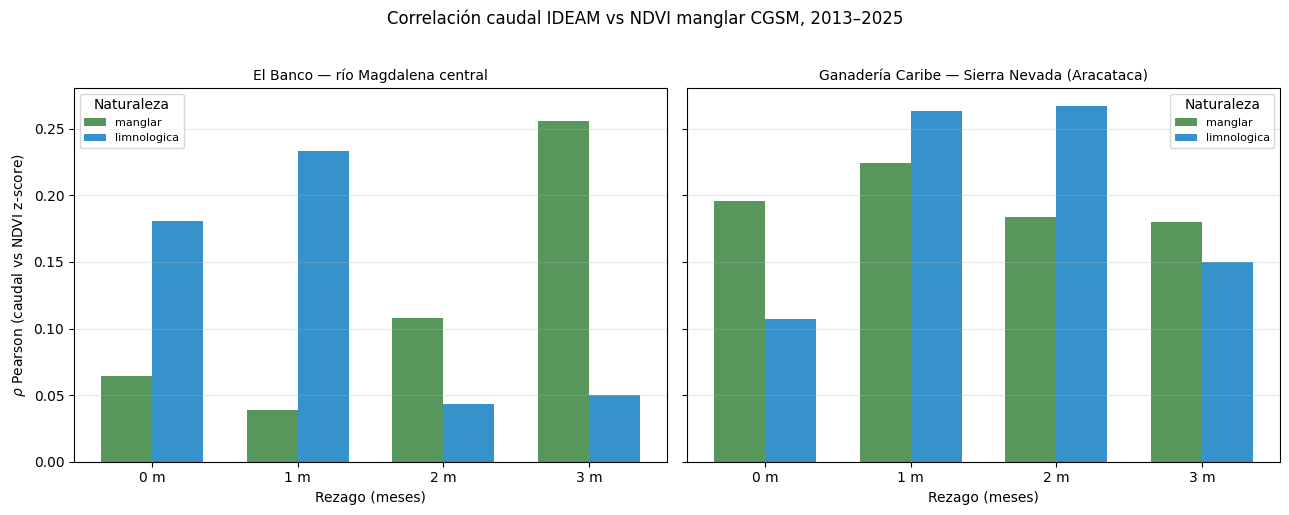

Guardado: caudal_vs_ndvi_correlacion.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
titulos = {
    'El_Banco_Magdalena': 'El Banco — río Magdalena central',
    'Ganaderia_Caribe_Aracataca': 'Ganadería Caribe — Sierra Nevada (Aracataca)',
}
x = np.arange(4); w = 0.35
for ax, est in zip(axes, titulos):
    for i, nat in enumerate(['manglar', 'limnologica']):
        sub = df_corr[(df_corr.estacion == est) & (df_corr.naturaleza == nat)].sort_values('rezago_meses')
        color = '#2E7D32' if nat == 'manglar' else '#0277BD'
        ax.bar(x + (i - 0.5) * w, sub['rho_caudal'], width=w, label=nat, color=color, alpha=0.8)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels([f'{i} m' for i in range(4)])
    ax.set_xlabel('Rezago (meses)')
    ax.set_title(titulos[est], fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Naturaleza', fontsize=8)
axes[0].set_ylabel(r'$\rho$ Pearson (caudal vs NDVI z-score)')
fig.suptitle('Correlación caudal IDEAM vs NDVI manglar CGSM, 2013–2025', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_FIG / 'caudal_vs_ndvi_correlacion.png', dpi=200, bbox_inches='tight')
plt.show()
print('Guardado: caudal_vs_ndvi_correlacion.png')

## 6. Interpretación esperada

La hipótesis central del informe es que el caudal anómalamente alto del río Magdalena durante La Niña 2020--2022 ---visible como barras rojas en el panel superior de la serie temporal--- precede al estrés del dosel del manglar de la CGSM con rezagos de 1 a 3 meses. Para la estación El Banco se espera una correlación negativa entre caudal z-score y NDVI z-score de las cuatro estaciones de manglar real, en este sentido el flujo del Magdalena llega al sistema lagunar por los canales rehabilitados Caño Clarín, Aguas Negras y Renegado, e induce inundación prolongada sobre el Complejo de Pajarales en una ventana temporal del orden de meses por el tránsito y la respuesta del manglar. Para la estación Ganadería Caribe sobre el río Aracataca ---tributario menor que drena directamente la Sierra Nevada---, el acoplamiento debería ser más rápido y de magnitud similar pero con rezago de 0 a 1 mes, así la diferencia entre ambas señales contrasta los dos mecanismos hidrológicos del sistema. Si las correlaciones con caudal alcanzan valores de $|\rho| > 0{,}25$ a uno de los rezagos en al menos una de las dos cuencas, queda cuantitativamente cerrada la cadena causal *La Niña → caudal fluvial → inundación lagunar → mortandad del manglar* con datos oficiales del IDEAM, lo que constituye el cierre final del análisis de forzamiento climático del proyecto.

En las estaciones limnológicas el signo esperado es positivo, pues el incremento de caudal aporta sedimentos y nutrientes que estimulan la productividad acuática sobre la lámina de agua del complejo lagunar central.

In [9]:
import zipfile, pandas as pd
from pathlib import Path

ROOT = Path('/home/rstudio/work/proyecto-cgsm')
out_dir = ROOT / 'data' / 'raw' / 'ideam'
out_dir.mkdir(parents=True, exist_ok=True)

zips_nuevos = {
    'Reporte de información Hidrometeorológica de DHIME BANCO MEDIO.zip': 'descargaDhime_elbanco_medio.csv',
    'Reporte de información Hidrometeorológica de DHIME GAN MAX.zip':    'descargaDhime_ganaderia_maximo.csv',
}

for zip_name, csv_out_name in zips_nuevos.items():
    zip_path = ROOT / zip_name
    if not zip_path.exists():
        print(f'NO encontrado: {zip_name}')
        continue
    with zipfile.ZipFile(zip_path) as z:
        for name in z.namelist():
            with z.open(name) as src:
                content = src.read()
            dest = out_dir / csv_out_name
            with open(dest, 'wb') as f:
                f.write(content)
            print(f'OK: {zip_name[:50]}... → {dest.name}  ({len(content):,} bytes)')

# Inspeccionar los 4 CSVs disponibles
print('\n=== Inventario de las 4 series IDEAM ===')
for csv in sorted(out_dir.glob('descargaDhime*.csv')):
    df = pd.read_csv(csv)
    val = pd.to_numeric(df.Valor, errors='coerce')
    print(f'\n{csv.name}:')
    print(f'  Estación: {df.NombreEstacion.iloc[0]}')
    print(f'  Variable: {df.Parametro.iloc[0]}')
    print(f'  Meses: {len(df)} | rango {df.Fecha.min()[:10]} a {df.Fecha.max()[:10]}')
    print(f'  Caudal: media {val.mean():.1f} m³/s, max {val.max():.1f}, min {val.min():.1f}')

OK: Reporte de información Hidrometeorológica de DHIME... → descargaDhime_elbanco_medio.csv  (16,230 bytes)
OK: Reporte de información Hidrometeorológica de DHIME... → descargaDhime_ganaderia_maximo.csv  (16,230 bytes)

=== Inventario de las 4 series IDEAM ===

descargaDhime.csv:
  Estación: EL BANCO - AUT [25027020]
  Variable: Caudal máximo mensual
  Meses: 144 | rango 2013-01-01 a 2025-12-01
  Caudal: media 4398.5 m³/s, max 7322.8, min 1654.8

descargaDhime_elbanco_medio.csv:
  Estación: EL BANCO - AUT [25027020]
  Variable: Caudal medio mensual
  Meses: 144 | rango 2013-01-01 a 2025-12-01
  Caudal: media 3749.6 m³/s, max 6861.1, min 1245.7

descargaDhime_ganaderia_caribe.csv:
  Estación: GANADERIA CARIBE  - AUT [29067150]
  Variable: Caudal medio mensual
  Meses: 130 | rango 2013-01-01 a 2025-12-01
  Caudal: media 15.8 m³/s, max 42.2, min 1.7

descargaDhime_ganaderia_maximo.csv:
  Estación: EL BANCO - AUT [25027020]
  Variable: Caudal medio mensual
  Meses: 144 | rango 2013-01-01 a